# **Predicting E-Commerce Purchase Likelihood Using an Optimized Classification Model**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv("/content/e_commerce_customer_data.csv")
df.head()

,CustomerID,Age,Gender,DeviceType,TrafficSource,PagesViewed,TimeOnSite,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,Purchase
0,C00001,56,Male,Mobile,Email,4,1,5,4,190,1,1
1,C00002,46,Female,Mobile,Social Media,9,1,3,0,266,0,0
2,C00003,32,Female,Desktop,Search Engine,7,7,4,7,85,1,1
3,C00004,25,Male,Mobile,Direct,5,4,2,1,87,0,0
4,C00005,38,Female,Mobile,Social Media,7,7,0,9,53,1,1


In [7]:
print(df.info)
print(df.describe())
print(df.shape)

<bound method DataFrame.info of      CustomerID  Age  Gender DeviceType  TrafficSource  PagesViewed  \
0        C00001   56    Male     Mobile          Email            4   
1        C00002   46  Female     Mobile   Social Media            9   
2        C00003   32  Female    Desktop  Search Engine            7   
3        C00004   25    Male     Mobile         Direct            5   
4        C00005   38  Female     Mobile   Social Media            7   
...         ...  ...     ...        ...            ...          ...   
4995     C04996   32    Male    Desktop   Social Media           13   
4996     C04997   36  Female    Desktop   Social Media            1   
4997     C04998   52  Female    Desktop          Email           10   
4998     C04999   34  Female    Desktop   Social Media            9   
4999     C05000   52  Female     Tablet          Email            1   

      TimeOnSite  CartItems  PreviousPurchases  AverageOrderValue  \
0              1          5                  4

In [8]:
print(df.isnull().sum())
print(df.duplicated().sum())


CustomerID           0
Age                  0
Gender               0
DeviceType           0
TrafficSource        0
PagesViewed          0
TimeOnSite           0
CartItems            0
PreviousPurchases    0
AverageOrderValue    0
DiscountUsed         0
Purchase             0
dtype: int64
0


In [9]:
df=df.drop_duplicates()

In [10]:
df['Purchase'].value_counts()

,count
Purchase,
1,2500
0,2500


In [11]:
df.shape

(5000, 12)

In [12]:
X=df.drop('Purchase',axis=1)
y=df['Purchase']

In [13]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols=X.select_dtypes(exclude=['object']).columns

In [14]:
num_cols

Index(['Age', 'PagesViewed', 'TimeOnSite', 'CartItems', 'PreviousPurchases',
       'AverageOrderValue', 'DiscountUsed'],
      dtype='object')

In [15]:
cat_cols

Index(['CustomerID', 'Gender', 'DeviceType', 'TrafficSource'], dtype='object')

In [16]:
cat_cols=cat_cols.drop('CustomerID')

In [17]:
cat_cols

Index(['Gender', 'DeviceType', 'TrafficSource'], dtype='object')

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [19]:
scale=StandardScaler()
ohe=OneHotEncoder(handle_unknown='ignore')

In [20]:
num_cols_processor=Pipeline(steps=[('imputer',SimpleImputer(strategy='mean')),('scale',scale)])
cat_cols_processor=Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('ohe',ohe)])

In [21]:
preprocessor=ColumnTransformer(transformers=[('num',num_cols_processor,num_cols),('cat',cat_cols_processor,cat_cols)])

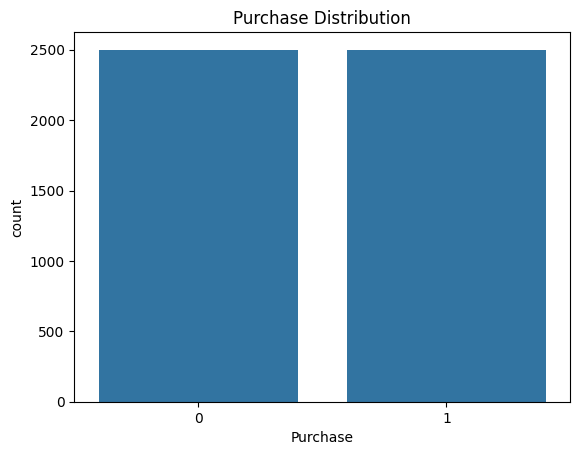

,proportion
Purchase,
1,0.5
0,0.5


In [22]:
sns.countplot(x='Purchase', data=df)
plt.title("Purchase Distribution")
plt.show()

df['Purchase'].value_counts(normalize=True)

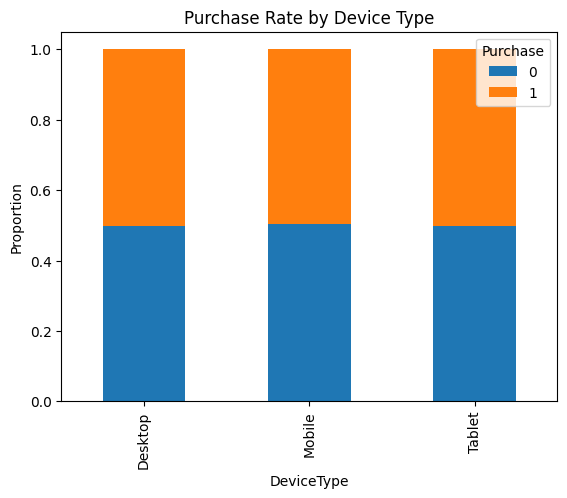

In [23]:
pd.crosstab(df['DeviceType'], df['Purchase'], normalize='index') \
  .plot(kind='bar', stacked=True)

plt.title("Purchase Rate by Device Type")
plt.ylabel("Proportion")
plt.show()

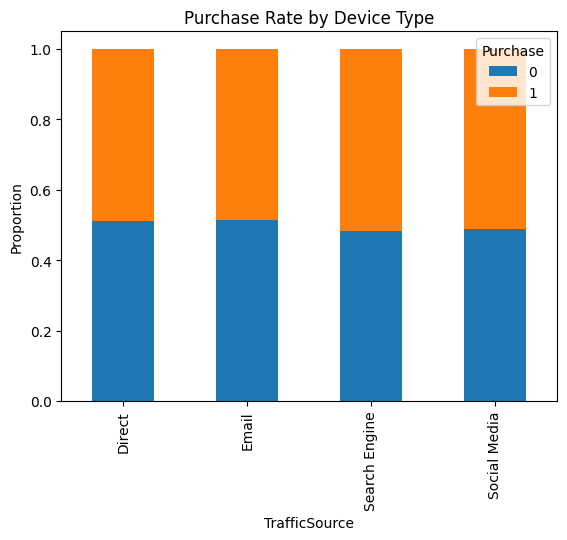

In [24]:
pd.crosstab(df['TrafficSource'], df['Purchase'], normalize='index') \
  .plot(kind='bar', stacked=True)

plt.title("Purchase Rate by Device Type")
plt.ylabel("Proportion")
plt.show()

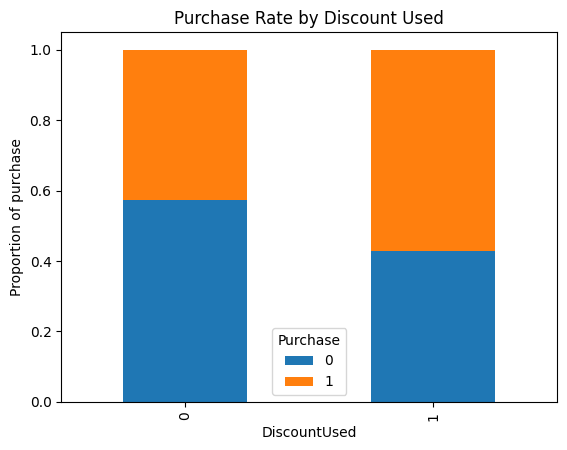

In [25]:
pd.crosstab(df['DiscountUsed'],df['Purchase'],normalize='index') \
  .plot(kind='bar',stacked=True)

plt.title("Purchase Rate by Discount Used")
plt.ylabel("Proportion of purchase")
plt.show()

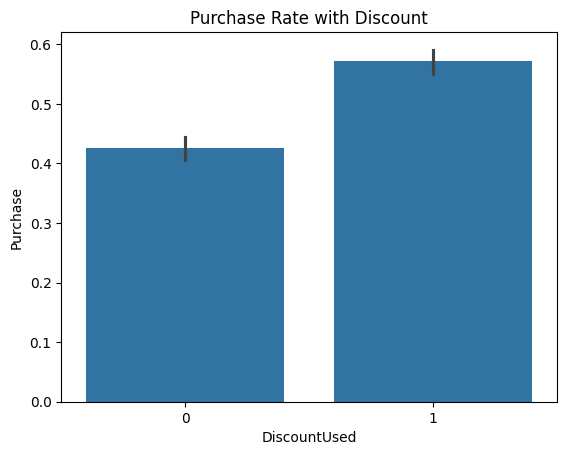

In [26]:
sns.barplot(x='DiscountUsed', y='Purchase', data=df)
plt.title("Purchase Rate with Discount")
plt.show()



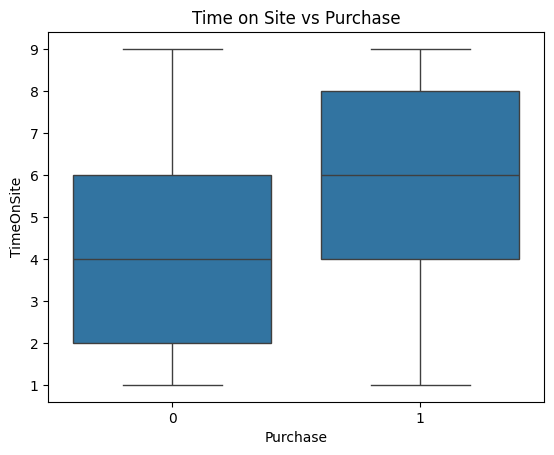

In [27]:
sns.boxplot(x='Purchase', y='TimeOnSite', data=df)
plt.title("Time on Site vs Purchase")
plt.show()

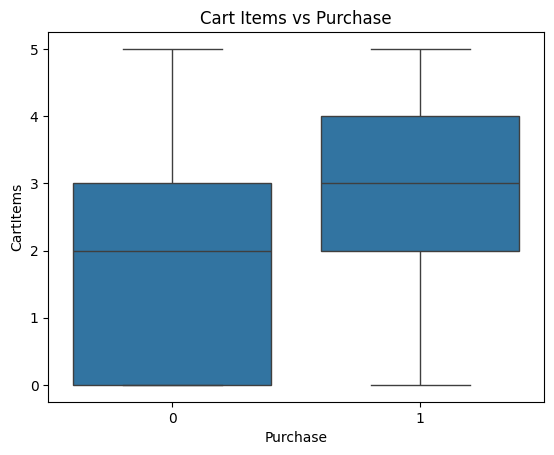

In [28]:
sns.boxplot(x='Purchase', y='CartItems', data=df)
plt.title("Cart Items vs Purchase")
plt.show()

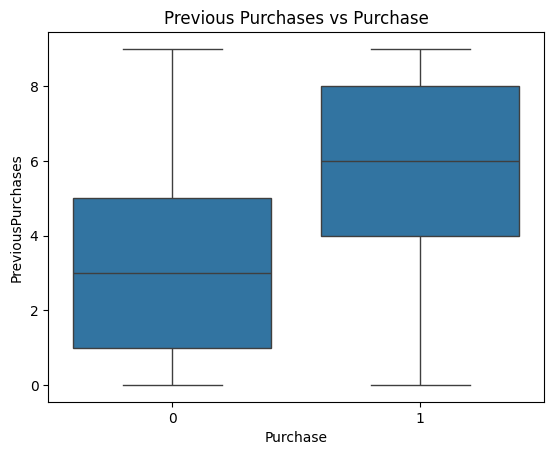

In [29]:
sns.boxplot(x='Purchase',y='PreviousPurchases',data=df)
plt.title("Previous Purchases vs Purchase")
plt.show()

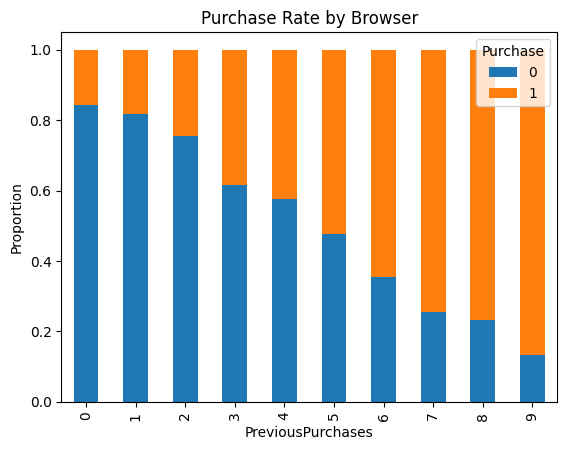

In [30]:
pd.crosstab(df['PreviousPurchases'], df['Purchase'], normalize='index') \
  .plot(kind='bar', stacked=True)

plt.title("Purchase Rate by Browser")
plt.ylabel("Proportion")
plt.show()

<Axes: >

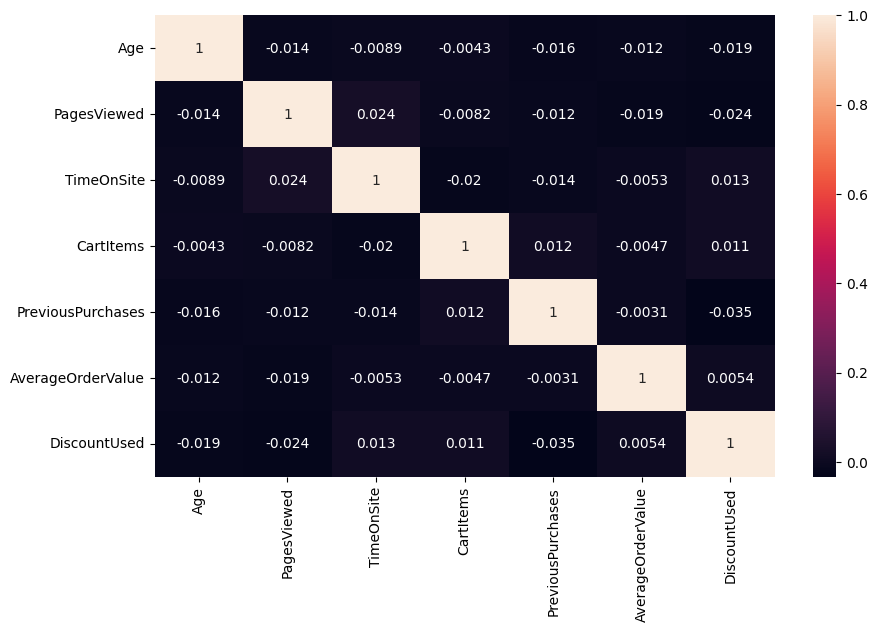

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(),annot=True)

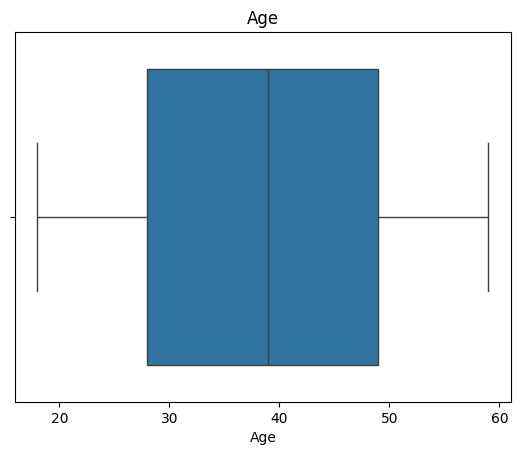

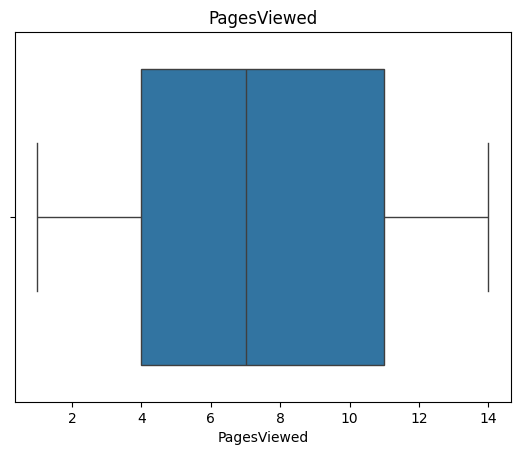

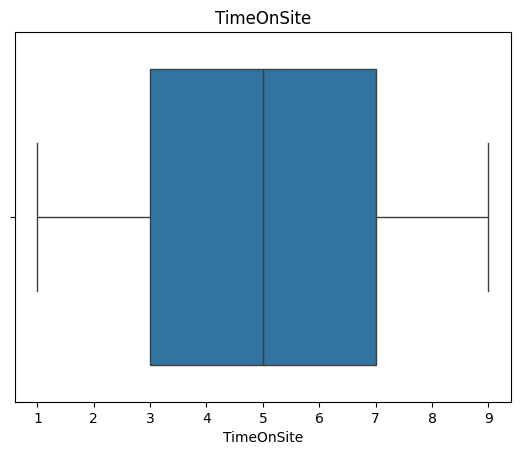

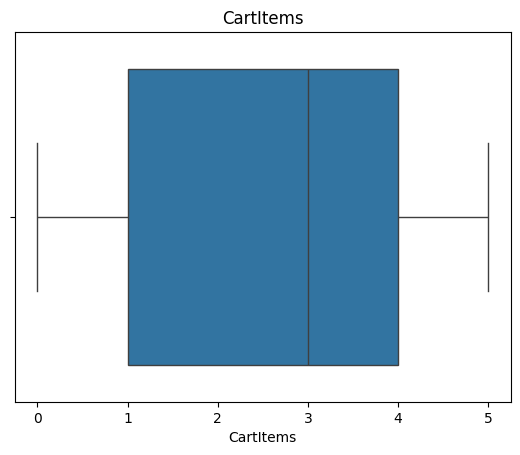

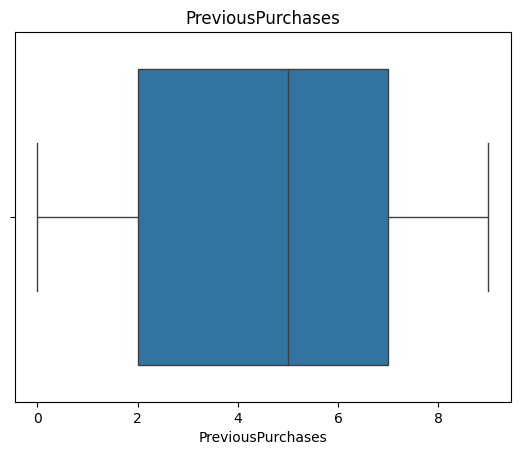

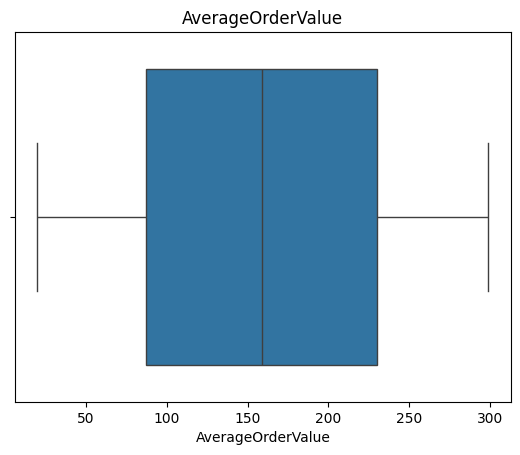

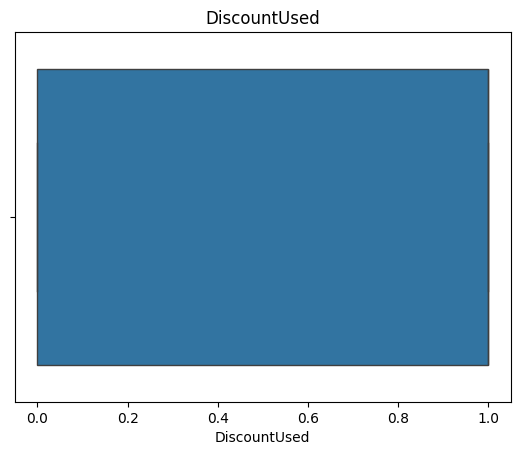

In [32]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,recall_score,precision_score,roc_auc_score
from sklearn.model_selection import GridSearchCV

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [35]:
model_log=Pipeline(steps=[('processor',preprocessor),('model',LogisticRegression())])
model_tree=Pipeline(steps=[('processor',preprocessor),('model',DecisionTreeClassifier())])
model_forest=Pipeline(steps=[('processor',preprocessor),('model',RandomForestClassifier())])

In [36]:
model_log.fit(X_train,y_train)
model_tree.fit(X_train,y_train)
model_forest.fit(X_train,y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'PagesViewed', 'TimeOnSite', 'CartItems', 'PreviousPurchases',
       'AverageOrderValue', 'DiscountUsed'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender', 'DeviceType', 'TrafficSource'], dtype='object'))])),
                ('model', RandomForestClassifier())])

In [37]:
y_pred_log=model_log.predict(X_test)
y_pred_tree=model_tree.predict(X_test)
y_pred_forest=model_forest.predict(X_test)

In [38]:
prob=model_log.predict_proba(X_test)[:,1]
print(prob)

[9.61084256e-02 9.89461263e-01 1.10999368e-01 9.92294077e-01
 9.81978133e-01 8.07926007e-01 9.85265928e-01 9.79912265e-01
 2.81863328e-01 1.40467710e-02 4.23439652e-03 4.39730315e-02
 4.47212812e-01 7.68212703e-02 3.20971662e-01 1.95776956e-01
 9.36053434e-01 1.56507359e-02 9.18373876e-01 9.00081956e-01
 9.99841855e-01 9.90964455e-01 5.09618346e-02 2.44775067e-03
 1.01103445e-02 7.90150662e-01 8.28175069e-02 6.07172418e-01
 1.51490398e-03 7.24440579e-02 1.63186092e-01 1.77325114e-01
 1.99591583e-01 9.57594145e-01 9.23953937e-02 3.60775065e-03
 9.05687948e-02 9.91197624e-01 9.86034851e-03 9.80038509e-01
 1.42048756e-01 2.40975727e-01 1.23886511e-02 1.71588562e-01
 8.89554631e-01 2.78402752e-02 3.08707135e-01 8.41374968e-01
 1.25375177e-02 5.79833432e-01 1.12919246e-03 2.49762623e-01
 8.14033009e-01 9.89530655e-01 7.38629903e-01 9.63196979e-01
 9.85405219e-01 1.13593755e-02 9.99909131e-01 9.68582644e-01
 1.32044391e-03 9.62470944e-01 3.34411476e-01 5.75512499e-01
 3.63409289e-01 5.783774

# **Logistic Regression**

In [39]:
print("Logistic Regression:")
print(classification_report(y_test,y_pred_log))
print(confusion_matrix(y_test,y_pred_log))
print(accuracy_score(y_test,y_pred_log))
print(precision_score(y_test,y_pred_log))
print(recall_score(y_test,y_pred_log))
print(f1_score(y_test,y_pred_log))
print(roc_auc_score(y_test,prob))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       500
           1       0.85      0.83      0.84       500

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000

[[426  74]
 [ 87 413]]
0.839
0.8480492813141683
0.826
0.8368794326241135
0.922124


In [40]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

In [41]:
grid = GridSearchCV(
    model_log,
    param_grid,
    cv=5,
    scoring="f1",   # IMPORTANT (better than accuracy)
    n_jobs=-1
)

In [42]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['Age', 'PagesViewed', 'TimeOnSite', 'CartItems', 'PreviousPurchases',
       'AverageOrderValue', 'DiscountUsed'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'DeviceType', 'TrafficSource'], dtype='object'))])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [43]:
print(grid.best_params_)
model_log=grid.best_estimator_

{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [44]:
y_pred_grid_log=grid.predict(X_test)
print("classification report=",classification_report(y_test,y_pred_grid_log))
print("confusion matrix",confusion_matrix(y_test,y_pred_grid_log))
print("accuracy score",accuracy_score(y_test,y_pred_grid_log))
print("precision score",precision_score(y_test,y_pred_grid_log))
print("recall score",recall_score(y_test,y_pred_grid_log))
print("f1 score ",f1_score(y_test,y_pred_grid_log))
print("roc_auc_score",roc_auc_score(y_test,prob))

classification report=               precision    recall  f1-score   support

           0       0.84      0.86      0.85       500
           1       0.85      0.83      0.84       500

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000

confusion matrix [[429  71]
 [ 84 416]]
accuracy score 0.845
precision score 0.8542094455852156
recall score 0.832
f1 score  0.8429584599797366
roc_auc_score 0.922124


# **Decision Tree**

In [45]:
param_grid = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__criterion": ["gini", "entropy"]
}
grid_dt = GridSearchCV(
    model_tree,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


In [46]:
grid_dt.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best Score: 0.8439406149583955


In [47]:
y_pred_grid_tree=grid_dt.predict(X_test)
print("classification report=",classification_report(y_test,y_pred_grid_tree))
print("confusion matrix",confusion_matrix(y_test,y_pred_grid_tree))
print("accuracy score",accuracy_score(y_test,y_pred_grid_tree))
print("precision score",precision_score(y_test,y_pred_grid_tree))
print("recall score",recall_score(y_test,y_pred_grid_tree))
print("f1 score ",f1_score(y_test,y_pred_grid_tree))
print("roc_auc_score",roc_auc_score(y_test,prob))

classification report=               precision    recall  f1-score   support

           0       0.79      0.79      0.79       500
           1       0.79      0.79      0.79       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000

confusion matrix [[396 104]
 [107 393]]
accuracy score 0.789
precision score 0.7907444668008048
recall score 0.786
f1 score  0.7883650952858575
roc_auc_score 0.922124


In [48]:
print("Decision Tree")
print(classification_report(y_test,y_pred_tree))
print(confusion_matrix(y_test,y_pred_tree))
print(accuracy_score(y_test,y_pred_tree))
print(precision_score(y_test,y_pred_tree))
print(recall_score(y_test,y_pred_tree))
print(f1_score(y_test,y_pred_tree))

Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       500
           1       0.76      0.71      0.74       500

    accuracy                           0.74      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.75      0.74      0.74      1000

[[388 112]
 [144 356]]
0.744
0.7606837606837606
0.712
0.7355371900826446


# **RandomForest**

In [49]:
grid_rf = GridSearchCV(
    estimator=model_forest,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__max_features": ["sqrt", "log2"]
    },
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['Age', 'PagesViewed', 'TimeOnSite', 'CartItems', 'PreviousPurchases',
       'AverageOrderValue', 'DiscountUsed'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy...
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'DeviceType', 'TrafficSource'], dtype='object'))])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [50]:
print(grid_rf.best_params_)
model_forest=grid_rf.best_estimator_

{'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [51]:
y_pred_grid_forest=grid_rf.predict(X_test)
print("classification report=",classification_report(y_test,y_pred_grid_forest))
print("confusion matrix",confusion_matrix(y_test,y_pred_grid_forest))
print("accuracy score",accuracy_score(y_test,y_pred_grid_forest))
print("precision score",precision_score(y_test,y_pred_grid_forest))
print("recall score",recall_score(y_test,y_pred_grid_forest))
print("f1 score ",f1_score(y_test,y_pred_grid_forest))
print("roc_auc_score",roc_auc_score(y_test,prob))

classification report=               precision    recall  f1-score   support

           0       0.83      0.84      0.84       500
           1       0.84      0.83      0.83       500

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000

confusion matrix [[421  79]
 [ 87 413]]
accuracy score 0.834
precision score 0.8394308943089431
recall score 0.826
f1 score  0.8326612903225806
roc_auc_score 0.922124


In [52]:
print("Random Forest")
print(classification_report(y_test,y_pred_forest))
print(confusion_matrix(y_test,y_pred_forest))
print(accuracy_score(y_test,y_pred_forest))
print(precision_score(y_test,y_pred_forest))
print(recall_score(y_test,y_pred_forest))
print(f1_score(y_test,y_pred_forest))

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       500
           1       0.85      0.81      0.83       500

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000

[[430  70]
 [ 94 406]]
0.836
0.8529411764705882
0.812
0.8319672131147541


**Among 3 models logistic regression models have the best accuracy so we optimized that model**




In [53]:
purchase_probabilities =model_log.predict_proba(X_test)[:, 1]

custom_predictions = (
    purchase_probabilities >= 0.40
).astype(int)

In [54]:
custom_predictions

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,

In [55]:
results = X_test.copy()

results["ActualPurchase"] = y_test.values
results["PurchaseProbability"] = purchase_probabilities

results["PurchaseLikelihood"] = pd.cut(
    results["PurchaseProbability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

In [56]:
results

,CustomerID,Age,Gender,DeviceType,TrafficSource,PagesViewed,TimeOnSite,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,ActualPurchase,PurchaseProbability,PurchaseLikelihood
2384,C02385,49,Male,Desktop,Email,12,6,3,0,89,0,0,0.193494,Low
3572,C03573,51,Male,Mobile,Social Media,12,6,3,9,118,0,1,0.943240,High
2886,C02887,42,Male,Desktop,Direct,11,6,2,0,101,1,0,0.208555,Low
3358,C03359,56,Female,Mobile,Direct,7,8,5,5,255,1,1,0.950332,High
2864,C02865,34,Female,Desktop,Direct,12,6,4,5,246,1,1,0.921389,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,C01078,50,Female,Desktop,Social Media,8,9,3,8,289,0,1,0.941631,High
979,C00980,55,Female,Mobile,Email,4,9,3,7,188,1,1,0.926844,High
1201,C01202,43,Male,Tablet,Search Engine,1,3,0,5,216,1,0,0.083547,Low
1478,C01479,57,Female,Mobile,Email,4,7,2,3,288,1,1,0.388714,Medium


In [58]:
model = grid_rf.best_estimator_.named_steps["model"]

feature_names = grid_rf.best_estimator_.named_steps["processor"].get_feature_names_out()


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

top_features = feature_importance.sort_values(
    by="Importance", ascending=False
).head(10)

print(top_features)

                             Feature  Importance
4             num__PreviousPurchases    0.462250
3                     num__CartItems    0.243098
2                    num__TimeOnSite    0.140738
1                   num__PagesViewed    0.080100
6                  num__DiscountUsed    0.031145
5             num__AverageOrderValue    0.015282
0                           num__Age    0.012618
14  cat__TrafficSource_Search Engine    0.002520
7                 cat__Gender_Female    0.001996
8                   cat__Gender_Male    0.001759


In [60]:
import joblib
joblib.dump(model_log,"log_model.pkl")

['log_model.pkl']

In [63]:
df.to_csv("updated_customer_data.csv")